Category distribution:
3    358977
5     86400
6     47316
0     37492
4      5814
2      4902
1         6
Name: count, dtype: int64
              precision    recall  f1-score   support

      AIRCON       0.98      0.97      0.97      7432
   Broadcast       0.50      1.00      0.67         1
        DOOR       0.98      0.98      0.98       986
       LIGHT       1.00      1.00      1.00     71673
      MOTION       0.98      0.98      0.98      1173
        OTBR       1.00      1.00      1.00     17253
        PLUG       0.98      0.98      0.98      9664

    accuracy                           0.99    108182
   macro avg       0.91      0.99      0.94    108182
weighted avg       0.99      0.99      0.99    108182

Weighted F1-Score: 0.9928


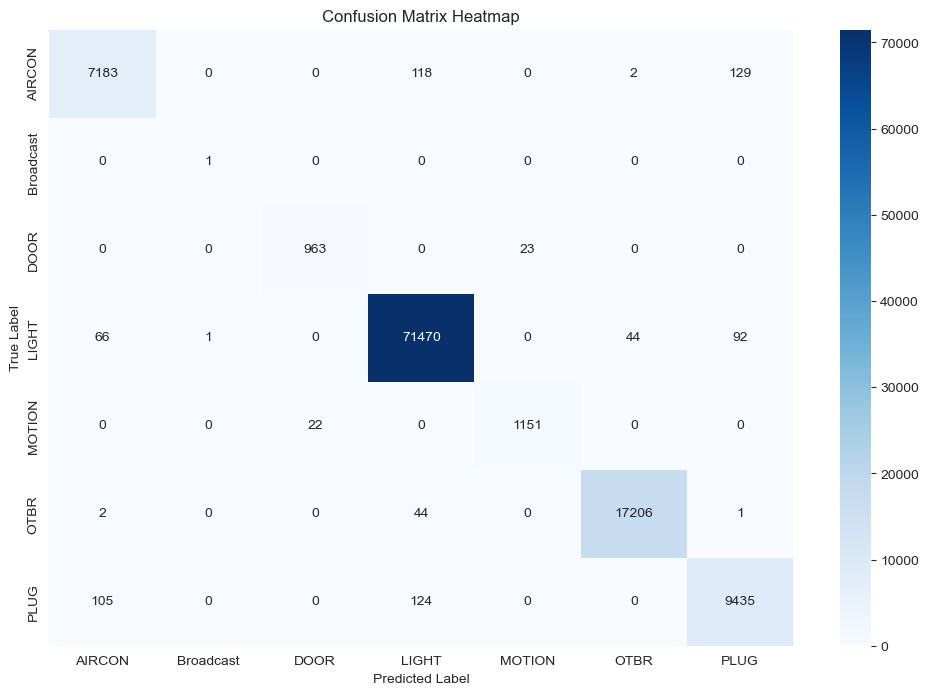

In [1]:
# Classification
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report,f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
file_path =  "D:/ZBIOT-2025/Dataset/Long captures/6-Merge-and-drop-unknown/fix_duration_5s.csv"
data = pd.read_csv(file_path)

X = data.drop(columns=["Device Name", "Device Type","File Name"])
y = data["Device Type"]

y = y.astype('category')
categories = y.cat.categories
y = y.cat.codes

print("Category distribution:")
print(pd.Series(y).value_counts())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

class_weights = compute_class_weight(class_weight="balanced", classes=pd.Series(y).unique(), y=y)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
actual_categories = sorted(set(y_test) | set(y_pred))
target_names = [categories[i] for i in actual_categories]
cm = confusion_matrix(y_test, y_pred, labels=actual_categories)

report = classification_report(y_test, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)

f1_macro = f1_score(y_test, y_pred, average="weighted")
print(f"Weighted F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()

### Identification

Category distribution:
13    86400
11    86336
10    86248
9     86246
4     85815
3     26841
7     24922
5     14332
12    13071
8     10651
6      9323
1      5814
0      4902
2         6
Name: count, dtype: int64
                   precision    recall  f1-score   support

Aqara Door/Window       0.98      0.98      0.98       986
     Aqara Motion       0.98      0.98      0.98      1173
        Broadcast       1.00      1.00      1.00         1
    ESP Arancione       0.97      0.96      0.97      5333
      ESP Azzurro       0.99      1.00      0.99     17235
       ESP Bianco       0.96      0.96      0.96      2857
       ESP Giallo       0.92      0.94      0.93      1867
        ESP Rosso       0.96      0.97      0.97      5147
        ESP Viola       0.96      0.95      0.95      2099
    Nanoleaf 0176       0.94      0.93      0.94     17112
    Nanoleaf 1624       0.92      0.92      0.92     17182
    Nanoleaf 2248       0.92      0.93      0.93     17287
            Onv

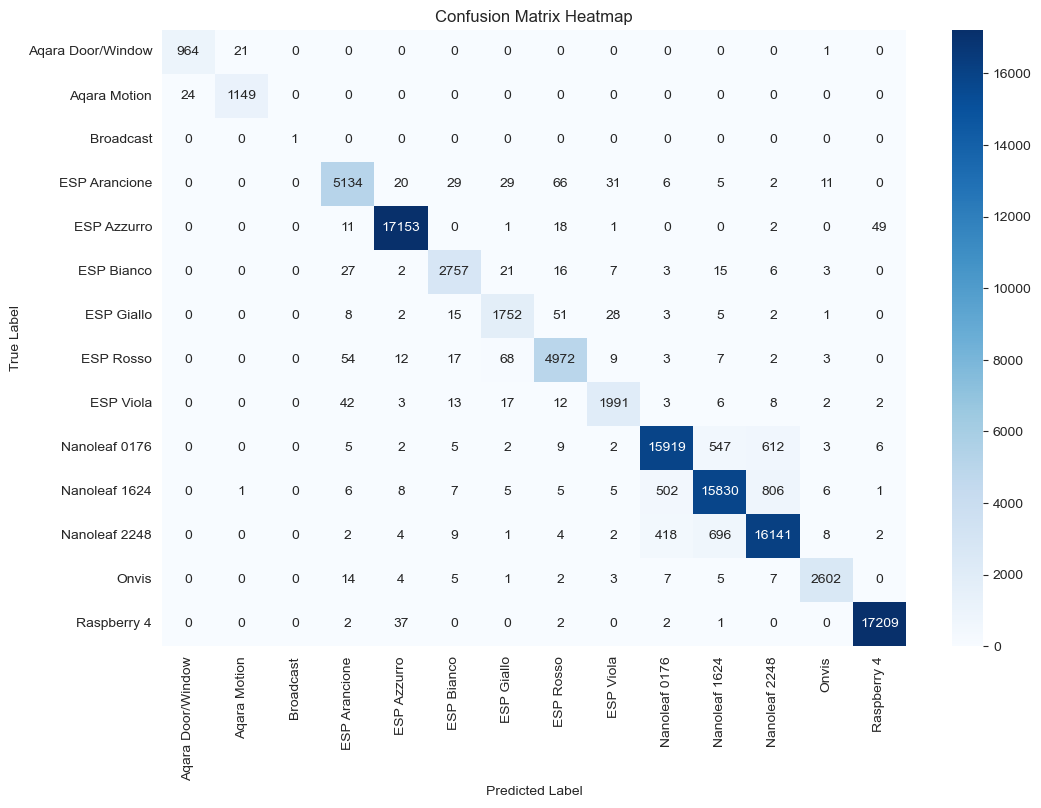

In [3]:
# Classification
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report,f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
file_path =  "D:/ZBIOT-2025/Dataset/Long captures/6-Merge-and-drop-unknown/fix_duration_5s.csv"
data = pd.read_csv(file_path)

X = data.drop(columns=["Device Name", "Device Type","File Name"])
y = data["Device Name"]

y = y.astype('category')
categories = y.cat.categories
y = y.cat.codes

print("Category distribution:")
print(pd.Series(y).value_counts())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

class_weights = compute_class_weight(class_weight="balanced", classes=pd.Series(y).unique(), y=y)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
actual_categories = sorted(set(y_test) | set(y_pred))
target_names = [categories[i] for i in actual_categories]
cm = confusion_matrix(y_test, y_pred, labels=actual_categories)

report = classification_report(y_test, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)

f1_macro = f1_score(y_test, y_pred, average="weighted")
print(f"Weighted F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()